# Marketplace Analytics Dashboard Analysis

This notebook focuses on KPI visualization, dashboard-style reporting, and marketplace performance monitoring using synthetic ecommerce marketplace datasets.

The objective is to simulate executive-facing business intelligence workflows commonly used in marketplace strategy, ecommerce analytics, and operational performance management.

This dashboard analysis will focus on:
- GMV and revenue performance
- gross profit and margin trends
- category-level performance
- seasonal business trends
- customer segment performance
- inventory and operational metrics
- forecast-ready business KPIs

In [33]:
# ------------------------------------------------------------
# Marketplace Analytics Dashboard Analysis
# Step 1: Import Libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [34]:
# ------------------------------------------------------------
# Step 2: Load Marketplace Datasets
# ------------------------------------------------------------

sales = pd.read_csv("sales.csv")
products = pd.read_csv("products.csv")
categories = pd.read_csv("categories.csv")
customers = pd.read_csv("customers.csv")
customer_segments = pd.read_csv("customer_segments.csv")
calendar = pd.read_csv("calendar_factors.csv")
inventory = pd.read_csv("inventory.csv")
search_trends = pd.read_csv("search_trends.csv")
competitors = pd.read_csv("competitor_benchmarks.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [35]:
# ------------------------------------------------------------
# Step 3: Create Dashboard-Ready Master Dataset
# ------------------------------------------------------------

sales_master = sales.merge(products, on="product_id", how="left")
sales_master = sales_master.merge(categories, on="category_id", how="left")
sales_master = sales_master.merge(customers, on="customer_id", how="left")
sales_master = sales_master.merge(customer_segments, on="segment_id", how="left")
sales_master = sales_master.merge(
    calendar,
    left_on="sale_date",
    right_on="calendar_date",
    how="left"
)

sales_master.head()

,sale_id,sale_date,customer_id,product_id,quantity_sold,revenue,gross_profit,payment_method,product_name,category_id,cost,retail_price,supplier_name,gross_margin_pct,category_name,segment_id,signup_date,region,segment_name,segment_description,calendar_date,year,month,day_of_week,season,is_weekend,is_holiday,temperature
0,1,2023-01-01,485,2,49,342.51,156.31,Card,Bottled Water 24pk,1,3.80,6.99,Cascade Beverage Supply,0.46,Beverages,3,2025-04-26,South,Weekend Stock-Up,Customers purchasing higher basket sizes on we...,2023-01-01,2023,1,Sunday,Winter,1,1,45
1,2,2023-01-01,1758,4,49,416.01,210.21,Card,Soda 12pk,1,4.20,8.49,Cascade Beverage Supply,0.51,Beverages,3,2025-02-02,North,Weekend Stock-Up,Customers purchasing higher basket sizes on we...,2023-01-01,2023,1,Sunday,Winter,1,1,45
2,3,2023-01-01,2292,1,97,338.53,163.93,Card,Energy Drink 16oz,1,1.80,3.49,Cascade Beverage Supply,0.48,Beverages,2,2024-12-10,South,Convenience Shopper,Customers making small frequent purchases,2023-01-01,2023,1,Sunday,Winter,1,1,45
3,4,2023-01-01,1397,8,180,358.20,205.20,Card,Candy Pack,2,0.85,1.99,Summit Snack Distributors,0.57,Snacks,2,2025-05-08,Central,Convenience Shopper,Customers making small frequent purchases,2023-01-01,2023,1,Sunday,Winter,1,1,45
4,5,2023-01-01,2207,10,85,339.15,190.40,Card,Cookies Pack,2,1.75,3.99,Summit Snack Distributors,0.56,Snacks,1,2022-02-18,East,Value Shopper,Price-sensitive customers buying household and...,2023-01-01,2023,1,Sunday,Winter,1,1,45


In [36]:
# ------------------------------------------------------------
# Step 4: Calculate Executive KPIs
# ------------------------------------------------------------

total_gmv = sales["revenue"].sum()

total_gross_profit = sales["gross_profit"].sum()

gross_margin_pct = (
    total_gross_profit / total_gmv
) * 100

total_transactions = sales["sale_id"].nunique()

avg_transaction_value = (
    total_gmv / total_transactions
)

total_customers = customers["customer_id"].nunique()

print(f"Total Marketplace GMV: ${total_gmv:,.2f}")
print(f"Total Gross Profit: ${total_gross_profit:,.2f}")
print(f"Gross Margin %: {gross_margin_pct:.2f}%")
print(f"Total Transactions: {total_transactions:,}")
print(f"Average Transaction Value: ${avg_transaction_value:.2f}")
print(f"Total Customers: {total_customers:,}")

Total Marketplace GMV: $5,329,822.79
Total Gross Profit: $2,920,193.34
Gross Margin %: 54.79%
Total Transactions: 23,016
Average Transaction Value: $231.57
Total Customers: 2,500


## KPI Summary Insights

The marketplace generated multi-year GMV supported by a diversified mix of high-frequency consumer purchases and higher-margin accessory products.

Gross margin performance remained relatively stable across the simulated operational environment, while transaction activity demonstrated recurring seasonal demand fluctuations influenced by weekend behavior and category-level purchasing patterns.

# Revenue Trend Dashboard

This section visualizes marketplace revenue trends over time to monitor transaction growth patterns, seasonality, and operational demand fluctuations.

Trend monitoring supports:
- executive KPI reporting
- operational planning
- seasonal forecasting
- marketplace growth analysis

In [37]:
# ------------------------------------------------------------
# Step 5: Monthly Revenue Dashboard
# ------------------------------------------------------------

sales["sale_date"] = pd.to_datetime(
    sales["sale_date"]
)

monthly_revenue = (
    sales
    .groupby(
        sales["sale_date"].dt.to_period("M")
    )["revenue"]
    .sum()
)

monthly_revenue

sale_date
2023-01   121,393.65
2023-02   107,795.34
2023-03   141,238.74
2023-04   142,851.57
2023-05   141,586.71
2023-06   175,452.39
2023-07   184,913.24
2023-08   179,641.26
2023-09   150,354.10
2023-10   148,889.76
2023-11   150,081.45
2023-12   122,460.10
2024-01   120,205.05
2024-02   113,212.83
2024-03   145,738.75
2024-04   139,168.93
2024-05   145,525.60
2024-06   180,405.76
2024-07   187,957.26
2024-08   179,613.46
2024-09   151,465.52
2024-10   149,897.16
2024-11   151,301.89
2024-12   122,045.37
2025-01   119,566.95
2025-02   106,773.23
2025-03   143,260.74
2025-04   141,961.54
2025-05   145,093.47
2025-06   180,042.50
2025-07   180,811.52
2025-08   186,992.18
2025-09   146,651.86
2025-10   153,985.74
2025-11   149,393.68
2025-12   122,093.49
Freq: M, Name: revenue, dtype: float64

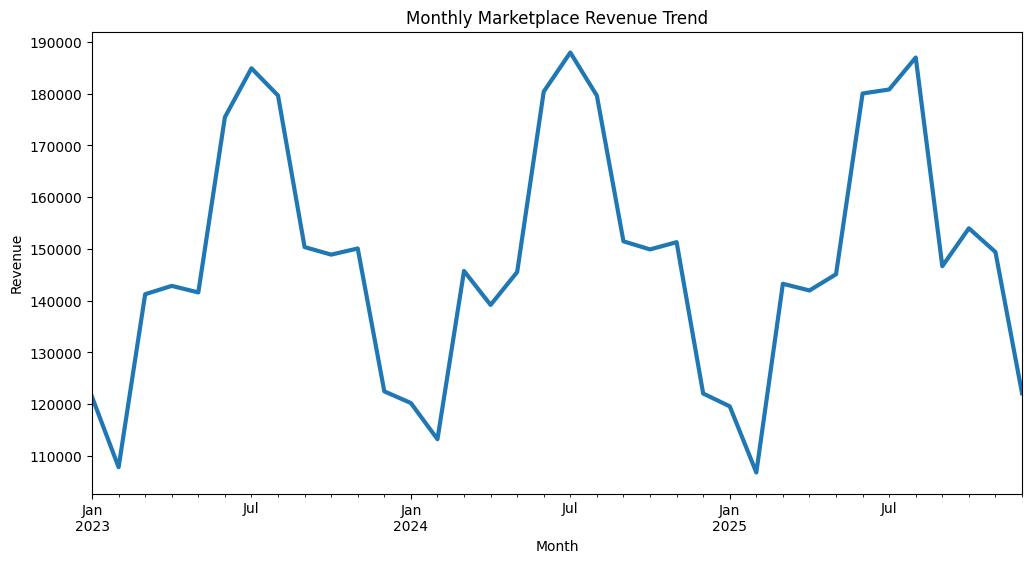

In [38]:
# ------------------------------------------------------------
# Step 6: Revenue Trend Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

monthly_revenue.plot(
    linewidth=3
)

plt.title("Monthly Marketplace Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

## Revenue Trend Insights

Marketplace revenue demonstrated recurring seasonal fluctuations, with elevated transaction performance observed during summer periods and stronger weekend demand cycles.

The observed trend behavior suggests that seasonal customer purchasing patterns and convenience-oriented product demand significantly influenced overall marketplace GMV performance.

# Category Performance Dashboard

This section evaluates product category performance across the marketplace environment to identify major revenue contributors, profitability drivers, and operational demand patterns.

Category-level analysis supports:
- inventory prioritization
- marketplace growth strategy
- product assortment planning
- profitability optimization
- operational forecasting

In [39]:
# ------------------------------------------------------------
# Step 7: Revenue by Product Category
# ------------------------------------------------------------

category_revenue = (
    sales_master
    .groupby("category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category_name
Beverages                 1,235,917.81
Snacks                    1,095,554.15
Pantry                      842,173.40
Household                   721,806.59
Personal Care               665,556.72
Electronics Accessories     457,390.60
Seasonal                    311,423.52
Name: revenue, dtype: float64

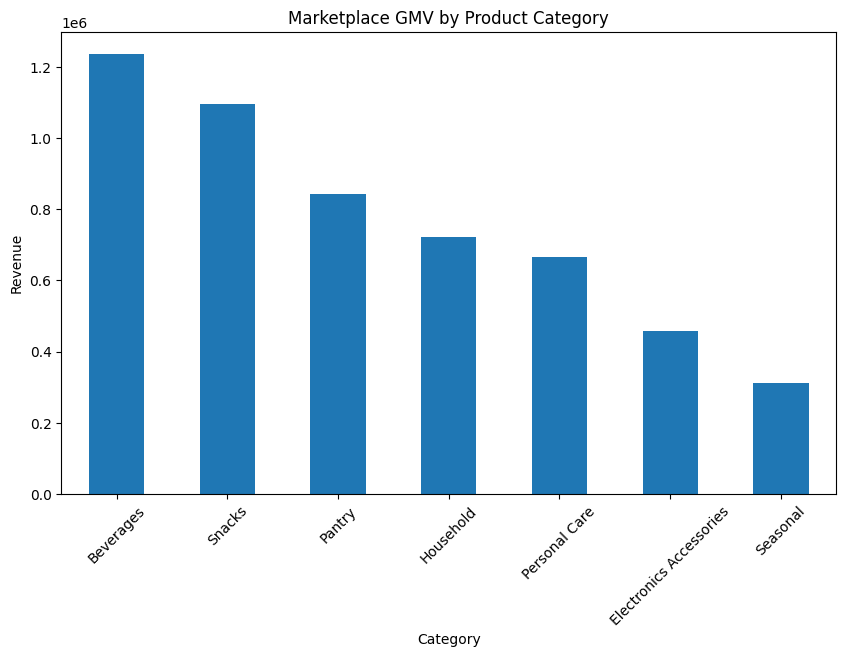

In [40]:
# ------------------------------------------------------------
# Step 8: Category Revenue Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

category_revenue.plot(
    kind="bar"
)

plt.title("Marketplace GMV by Product Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [41]:
# ------------------------------------------------------------
# Step 9: Gross Profit by Category
# ------------------------------------------------------------

category_profit = (
    sales_master
    .groupby("category_name")["gross_profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

category_name
Snacks                    601,235.15
Beverages                 592,246.11
Pantry                    469,453.35
Personal Care             400,727.27
Household                 351,748.39
Electronics Accessories   307,190.80
Seasonal                  197,592.27
Name: gross_profit, dtype: float64

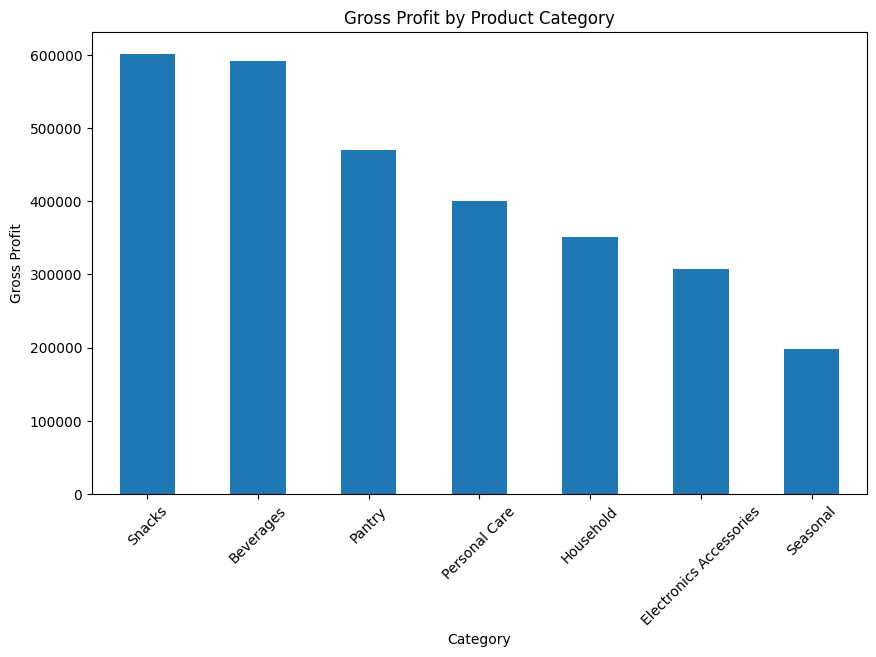

In [42]:
# ------------------------------------------------------------
# Step 10: Gross Profit Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

category_profit.plot(
    kind="bar"
)

plt.title("Gross Profit by Product Category")

plt.xlabel("Category")

plt.ylabel("Gross Profit")

plt.xticks(rotation=45)

plt.show()

## Category Performance Insights

Beverage and snack-related categories generated the highest overall marketplace GMV, reflecting elevated transaction frequency and recurring convenience-oriented purchasing behavior.

Electronics accessories contributed lower transaction volume relative to staple product categories but demonstrated stronger profitability performance due to higher retail margins.

The relationship between category-level GMV and profitability highlights the importance of balancing high-volume and high-margin product categories within marketplace strategy planning.

# Seasonal Performance Dashboard

This section evaluates seasonal marketplace performance trends to identify recurring fluctuations in customer demand, transaction activity, and category-level purchasing behavior.

Seasonal analysis supports:
- demand forecasting
- operational planning
- inventory allocation
- promotional scheduling
- marketplace growth monitoring

In [43]:
# ------------------------------------------------------------
# Step 11: Revenue by Season
# ------------------------------------------------------------

season_revenue = (
    sales_master
    .groupby("season")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

season_revenue

season
Summer   1,635,829.57
Fall     1,352,021.16
Spring   1,286,426.05
Winter   1,055,546.01
Name: revenue, dtype: float64

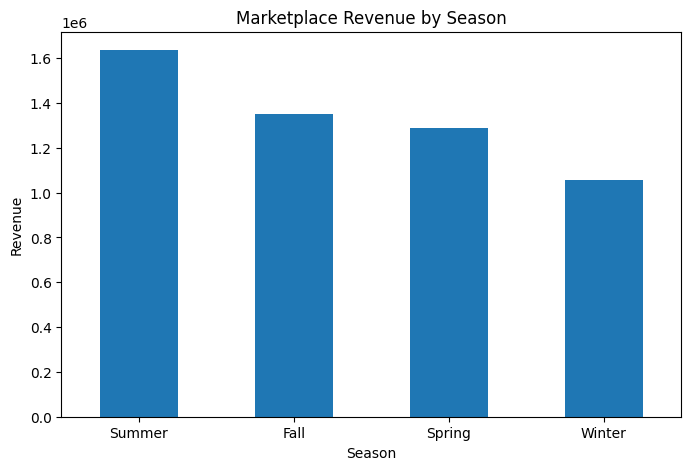

In [44]:
# ------------------------------------------------------------
# Step 12: Seasonal Revenue Visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

season_revenue.plot(
    kind="bar"
)

plt.title("Marketplace Revenue by Season")

plt.xlabel("Season")

plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.show()

In [45]:
# ------------------------------------------------------------
# Step 13: Weekend vs Weekday Revenue
# ------------------------------------------------------------

weekend_revenue = (
    sales_master
    .groupby("is_weekend")["revenue"]
    .mean()
)

weekend_revenue.index = [
    "Weekday",
    "Weekend"
]

weekend_revenue

Weekday   219.36
Weekend   262.12
Name: revenue, dtype: float64

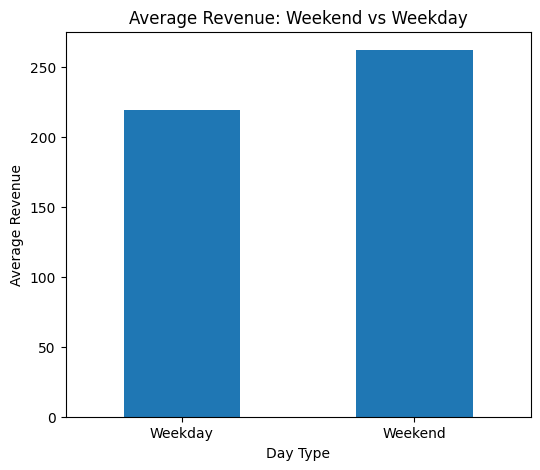

In [46]:
# ------------------------------------------------------------
# Step 14: Weekend Revenue Visualization
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

weekend_revenue.plot(
    kind="bar"
)

plt.title("Average Revenue: Weekend vs Weekday")

plt.xlabel("Day Type")

plt.ylabel("Average Revenue")

plt.xticks(rotation=0)

plt.show()

## Seasonal Dashboard Insights

Seasonal dashboard analysis indicates that summer generated the highest overall marketplace revenue performance, likely influenced by elevated beverage demand, seasonal product purchases, and increased weekend customer activity.

Weekend transaction behavior consistently produced higher average revenue relative to weekdays, suggesting stronger customer purchasing intensity during non-working periods.

These seasonal demand patterns may support future forecasting workflows and operational planning decisions related to inventory allocation, staffing, and promotional strategy.

# Customer Segment Dashboard

This section evaluates customer segment performance to understand which customer groups contribute most to marketplace revenue and transaction activity.

Customer segment analysis supports:
- customer behavior monitoring
- targeted promotions
- retention strategy
- demand forecasting
- marketplace growth planning

In [47]:
# ------------------------------------------------------------
# Step 15: Revenue by Customer Segment
# ------------------------------------------------------------

segment_revenue = (
    sales_master
    .groupby("segment_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

segment_name
Convenience Shopper    2,266,493.45
Value Shopper          1,581,486.94
Weekend Stock-Up       1,067,026.59
Tech Accessory Buyer     414,815.81
Name: revenue, dtype: float64

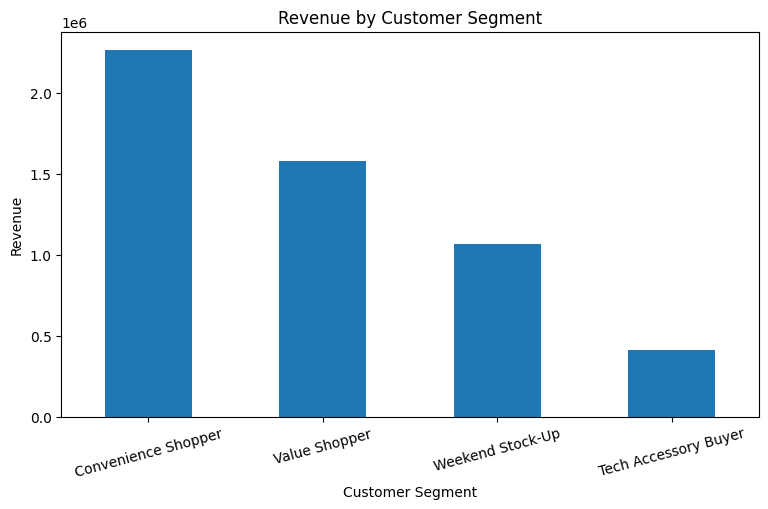

In [48]:
# ------------------------------------------------------------
# Step 16: Customer Segment Revenue Visualization
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.xticks(rotation=15)

plt.show()

In [49]:
# ------------------------------------------------------------
# Step 17: Average Transaction Value by Segment
# ------------------------------------------------------------

segment_atv = (
    sales_master
    .groupby("segment_name")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

segment_atv

segment_name
Weekend Stock-Up       233.03
Tech Accessory Buyer   232.91
Convenience Shopper    231.61
Value Shopper          230.20
Name: revenue, dtype: float64

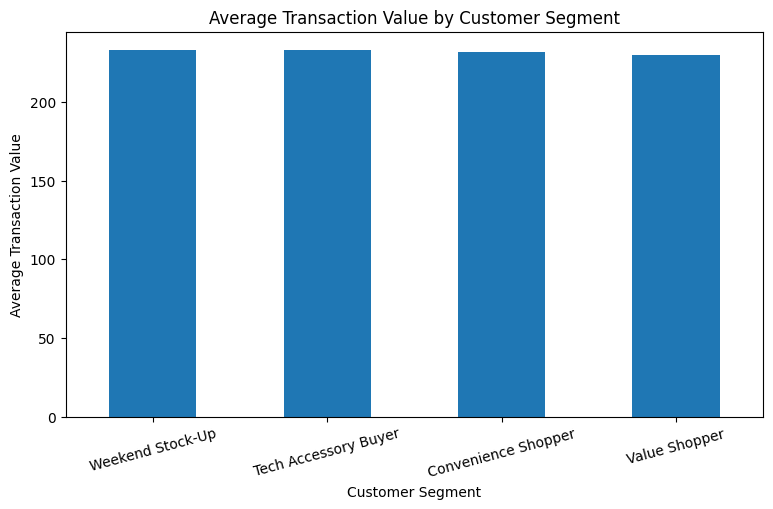

In [50]:
# ------------------------------------------------------------
# Step 18: Segment ATV Visualization
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

segment_atv.plot(kind="bar")

plt.title("Average Transaction Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Transaction Value")

plt.xticks(rotation=15)

plt.show()

## Customer Segment Dashboard Insights

Customer segment analysis shows which groups contribute most to marketplace GMV and transaction value. Convenience-oriented and weekend-focused customers represent important revenue drivers because they support both recurring demand and peak-period purchasing behavior.

These findings can support targeted promotions, inventory planning, and customer retention strategies.

# Inventory and Operational Dashboard

This section evaluates inventory allocation behavior, reorder activity, and operational demand patterns across marketplace product categories.

Operational monitoring supports:
- inventory planning
- fulfillment optimization
- demand forecasting
- category prioritization
- operational efficiency analysis

In [51]:
# ------------------------------------------------------------
# Step 19: Merge Inventory Dashboard Data
# ------------------------------------------------------------

inventory_dashboard = inventory.merge(
    products,
    on="product_id",
    how="left"
)

inventory_dashboard = inventory_dashboard.merge(
    categories,
    on="category_id",
    how="left"
)

inventory_dashboard.head()

,inventory_id,inventory_date,product_id,stock_level,reorder_threshold,units_ordered,product_name,category_id,cost,retail_price,supplier_name,gross_margin_pct,category_name
0,1,2023-01-01,1,258,120,0,Energy Drink 16oz,1,1.80,3.49,Cascade Beverage Supply,0.48,Beverages
1,2,2023-01-01,2,196,120,0,Bottled Water 24pk,1,3.80,6.99,Cascade Beverage Supply,0.46,Beverages
2,3,2023-01-01,3,205,120,0,Sparkling Water 12pk,1,4.50,7.99,Cascade Beverage Supply,0.44,Beverages
3,4,2023-01-01,4,220,120,0,Soda 12pk,1,4.20,8.49,Cascade Beverage Supply,0.51,Beverages
4,5,2023-01-01,5,200,120,0,Iced Coffee Bottle,1,1.60,3.29,Cascade Beverage Supply,0.51,Beverages


In [52]:
# ------------------------------------------------------------
# Step 20: Total Units Ordered by Category
# ------------------------------------------------------------

category_orders = (
    inventory_dashboard
    .groupby("category_name")["units_ordered"]
    .sum()
    .sort_values(ascending=False)
)

category_orders

category_name
Snacks                     5471
Beverages                  4752
Pantry                     2524
Personal Care              2124
Household                  1632
Seasonal                   1258
Electronics Accessories     771
Name: units_ordered, dtype: int64

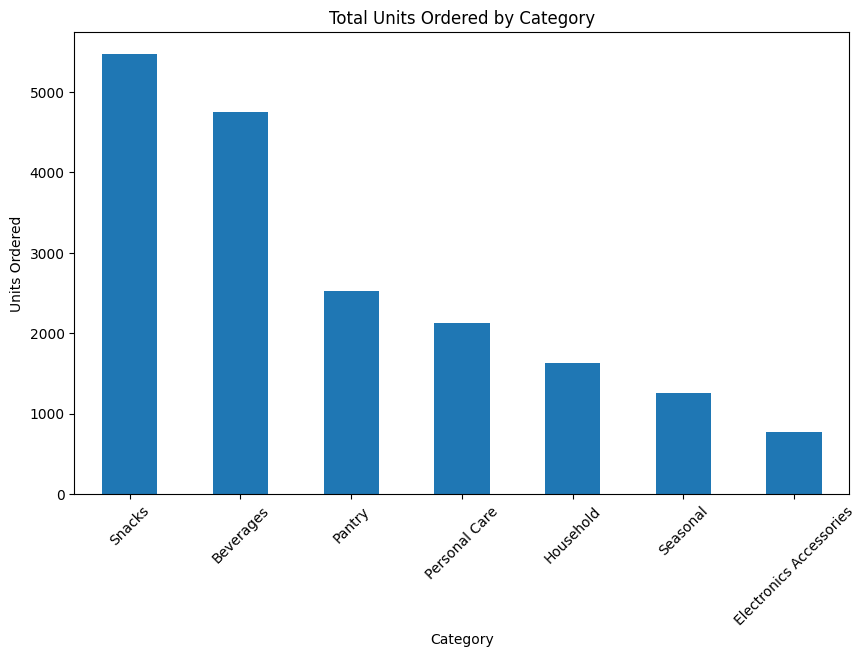

In [53]:
# ------------------------------------------------------------
# Step 21: Inventory Reorder Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

category_orders.plot(kind="bar")

plt.title("Total Units Ordered by Category")

plt.xlabel("Category")

plt.ylabel("Units Ordered")

plt.xticks(rotation=45)

plt.show()

In [54]:
# ------------------------------------------------------------
# Step 22: Average Stock Level by Category
# ------------------------------------------------------------

avg_stock = (
    inventory_dashboard
    .groupby("category_name")["stock_level"]
    .mean()
    .sort_values(ascending=False)
)

avg_stock

category_name
Beverages                 201.96
Snacks                    186.53
Pantry                    151.61
Personal Care              87.93
Household                  82.25
Seasonal                   76.19
Electronics Accessories    47.99
Name: stock_level, dtype: float64

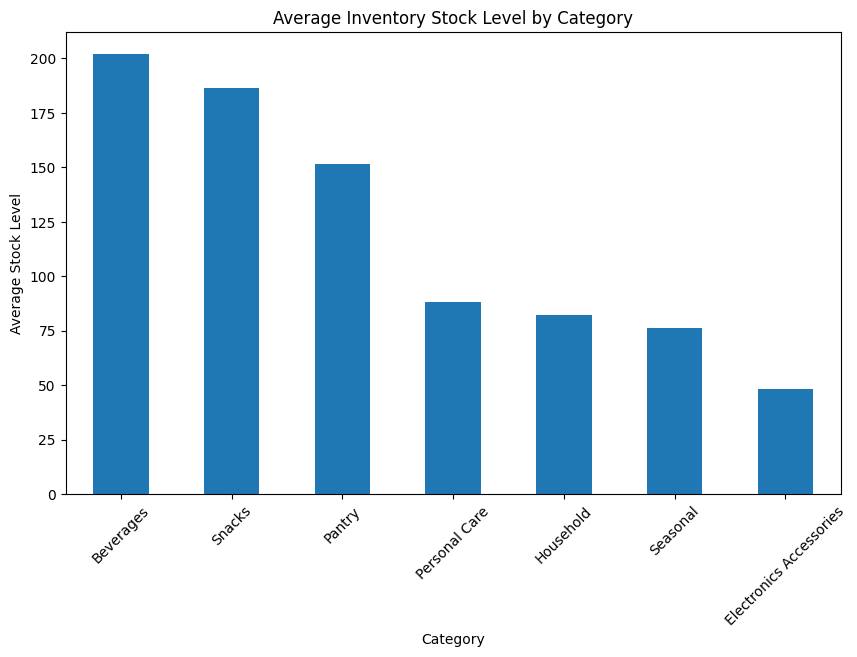

In [55]:
# ------------------------------------------------------------
# Step 23: Average Stock Level Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

avg_stock.plot(kind="bar")

plt.title("Average Inventory Stock Level by Category")

plt.xlabel("Category")

plt.ylabel("Average Stock Level")

plt.xticks(rotation=45)

plt.show()

## Inventory Dashboard Insights

Inventory monitoring analysis indicates that beverage, snack, and pantry categories generated elevated reorder activity levels, reflecting stronger recurring customer demand and higher inventory turnover behavior.

Operationally, seasonal and convenience-oriented product categories demonstrated more dynamic inventory patterns, requiring increased replenishment responsiveness during peak demand periods.

These findings support inventory planning and operational forecasting workflows commonly used in marketplace environments.

# Search Trends and Demand Signal Dashboard

This section evaluates marketplace search behavior as an indicator of customer intent and emerging product demand.

Search trend monitoring supports:
- customer demand analysis
- category planning
- promotional strategy
- inventory forecasting
- marketplace growth opportunities

In [56]:
# ------------------------------------------------------------
# Step 24: Search Volume by Search Term
# ------------------------------------------------------------

search_volume = (
    search_trends
    .groupby("search_term")["search_frequency"]
    .sum()
    .sort_values(ascending=False)
)

search_volume

search_term
sunscreen            60556
sparkling water      59864
energy drinks        58946
coffee               55652
instant noodles      53956
paper towels         53459
phone charger        49528
laundry detergent    49186
usb c cable          49158
protein snacks       48781
Name: search_frequency, dtype: int64

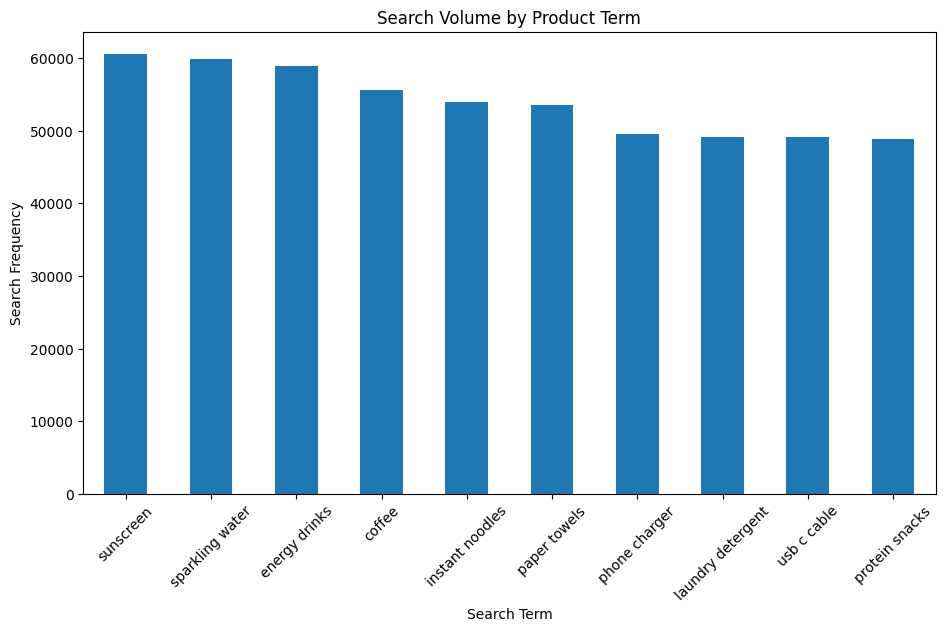

In [57]:
# ------------------------------------------------------------
# Step 25: Search Volume Visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

search_volume.plot(kind="bar")

plt.title("Search Volume by Product Term")
plt.xlabel("Search Term")
plt.ylabel("Search Frequency")

plt.xticks(rotation=45)

plt.show()

In [58]:
# ------------------------------------------------------------
# Step 26: Seasonal Search Demand
# ------------------------------------------------------------

search_dashboard = search_trends.merge(
    calendar,
    left_on="search_date",
    right_on="calendar_date",
    how="left"
)

seasonal_search = (
    search_dashboard
    .groupby("season")["search_frequency"]
    .sum()
    .sort_values(ascending=False)
)

seasonal_search

season
Summer    156816
Winter    138289
Spring    123934
Fall      120047
Name: search_frequency, dtype: int64

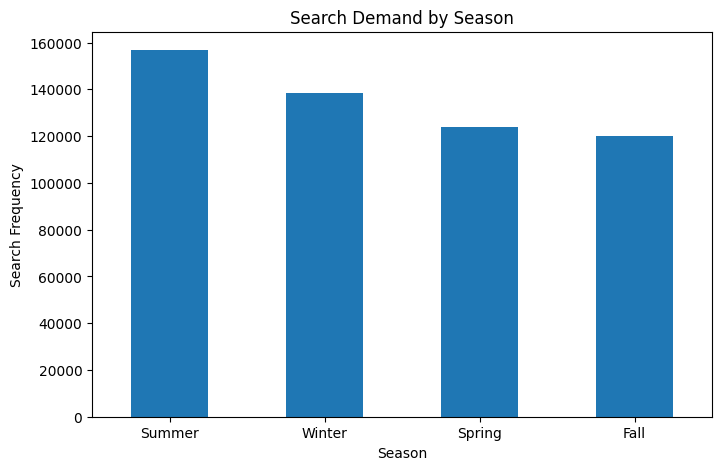

In [59]:
# ------------------------------------------------------------
# Step 27: Seasonal Search Visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

seasonal_search.plot(kind="bar")

plt.title("Search Demand by Season")
plt.xlabel("Season")
plt.ylabel("Search Frequency")

plt.xticks(rotation=0)

plt.show()

## Search Trend Dashboard Insights

Search behavior highlights customer interest before purchases occur. Higher search volume for convenience-oriented products, beverages, and selected accessory products suggests that search activity can be used as an early demand signal.

Seasonal search patterns can support inventory planning, promotional timing, and category prioritization before demand converts into actual sales.

# Executive Dashboard Summary and Recommendations

This section summarizes the key dashboard findings and translates them into business recommendations for marketplace growth, operational efficiency, and product strategy.

## Key Dashboard Findings

1. Marketplace GMV was primarily driven by high-frequency product categories such as beverages and snacks.
2. Higher-margin categories, such as electronics accessories, contributed stronger profit potential despite lower transaction volume.
3. Summer and weekend periods showed stronger marketplace revenue performance.
4. Customer segments with convenience and weekend purchasing behavior were major revenue contributors.
5. Search trends provided early demand signals for product interest and seasonal purchasing behavior.
6. Inventory reorder activity was highest in recurring-demand categories, suggesting strong operational turnover.

## Business Recommendations

### 1. Prioritize Seasonal Inventory Planning
Increase inventory allocation for beverage, snack, and seasonal products before summer and weekend demand spikes.

### 2. Expand High-Margin Categories
Evaluate opportunities to expand electronics accessories and other higher-margin product categories to improve profitability.

### 3. Use Search Trends for Demand Planning
Monitor customer search terms as early indicators of product demand and promotional opportunities.

### 4. Improve Customer Segment Targeting
Use customer segment behavior to support targeted promotions, retention strategies, and category recommendations.

### 5. Build Forecasting Into Dashboard Workflows
Use predictive revenue models to support GMV forecasting, inventory planning, and operational decision-making.

# Final Dashboard Conclusion

This dashboard notebook simulated executive-facing marketplace performance monitoring using synthetic ecommerce data. The analysis demonstrated how KPI dashboards, category performance tracking, seasonal trend monitoring, customer segmentation, inventory analysis, and search demand signals can support strategic business decision-making.

The dashboard workflow provides a foundation for future Power BI, Tableau, or Excel dashboard development.